# 05 — XGBoost

Implements an XGBoost model for financial time series forecasting.

Unlike ARIMA and Moving Average, XGBoost is a **machine learning** model — it does not understand sequential order on its own. Instead, we manually create features from past values (lags and rolling statistics) so the model can learn patterns from historical data.

**Key idea:** turn the time series problem into a supervised learning problem.
Each row becomes: `[lag_1, lag_2, ..., rolling_mean, rolling_std] → next_day_price`

**Input:** `data/processed/<TICKER>_train.csv` and `data/processed/<TICKER>_test.csv`

In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error


## Parameters

- `N_LAGS` — how many past days to use as input features
- `ROLLING_WINDOW` — window size for rolling mean and std features
- XGBoost hyperparameters: `N_ESTIMATORS`, `MAX_DEPTH`, `LEARNING_RATE`

In [108]:
TICKER         = 'AAPL'
N_LAGS         = 10    # number of past days used as features
ROLLING_WINDOW = 5     # window for rolling mean and std features
N_ESTIMATORS   = 200   # number of boosting rounds
MAX_DEPTH      = 4     # maximum depth of each tree
LEARNING_RATE  = 0.05  # step size shrinkage to prevent overfitting


## Load Data

In [109]:
train = pd.read_csv(f'../data/processed/{TICKER}_train.csv', index_col='Date', parse_dates=True)
test  = pd.read_csv(f'../data/processed/{TICKER}_test.csv',  index_col='Date', parse_dates=True)

print(f"Train: {len(train)} rows | Test: {len(test)} rows")

Train: 1205 rows | Test: 302 rows


## Feature Engineering

We predict the **absolute next-day Close price** directly.

Features created:
- **Lag prices** (`lag_1` to `lag_N`): Close price from 1, 2, ..., N days ago
- **Rolling mean** (`rolling_mean`): average Close over the last `ROLLING_WINDOW` days
- **Rolling std** (`rolling_std`): volatility over the last `ROLLING_WINDOW` days
- **Target** (`target`): next day's Close price

**Note:** XGBoost cannot extrapolate beyond the price range seen in training.
If test prices exceed the training range, predictions will stay near the training mean.


In [110]:
full = pd.concat([train, test])

# Lag features: past N close prices
for lag in range(1, N_LAGS + 1):
    full[f'lag_{lag}'] = full['Close'].shift(lag)

# Rolling statistics
# shift(1) ensures we only use data available BEFORE the current day (no leakage)
full['rolling_mean'] = full['Close'].shift(1).rolling(window=ROLLING_WINDOW).mean()
full['rolling_std']  = full['Close'].shift(1).rolling(window=ROLLING_WINDOW).std()

# Target: next day's absolute Close price
full['target'] = full['Close'].shift(-1)

# Drop rows where features are NaN
feature_cols_all = [f'lag_{i}' for i in range(1, N_LAGS + 1)] + ['rolling_mean', 'rolling_std']
full.dropna(subset=feature_cols_all, inplace=True)

print(f"Total rows: {len(full)}")


Total rows: 1497


## Train / Test Split

We split back into train and test using the original index dates.
The split is chronological — no rows from the future appear in training.

In [111]:
feature_cols = [f'lag_{i}' for i in range(1, N_LAGS + 1)] + ['rolling_mean', 'rolling_std']

train_feat = full.loc[full.index.isin(train.index)]
test_feat  = full.loc[full.index.isin(test.index)]

train_feat = train_feat.dropna(subset=['target'])

X_train = train_feat[feature_cols]
y_train = train_feat['target']

X_test  = test_feat[feature_cols]
y_test  = test_feat['target'].dropna()

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")


X_train: (1195, 12) | X_test: (302, 12)


## Train XGBoost

In [112]:
model = XGBRegressor(
    n_estimators=N_ESTIMATORS,
    max_depth=MAX_DEPTH,
    learning_rate=LEARNING_RATE,
    random_state=42,
    verbosity=0,
)

model.fit(X_train, y_train)

print("Training complete.")

Training complete.


## Predictions

In [113]:
# Predict only on rows where we have a valid target (301 rows, last row excluded)
predictions = model.predict(X_test.loc[y_test.index])
actuals     = y_test.values

print(f"Predictions: {predictions.shape} | Actuals: {actuals.shape}")


Predictions: (301,) | Actuals: (301,)


## Metrics

MAE:  16.9743
RMSE: 23.9767
MAPE: 6.7833%


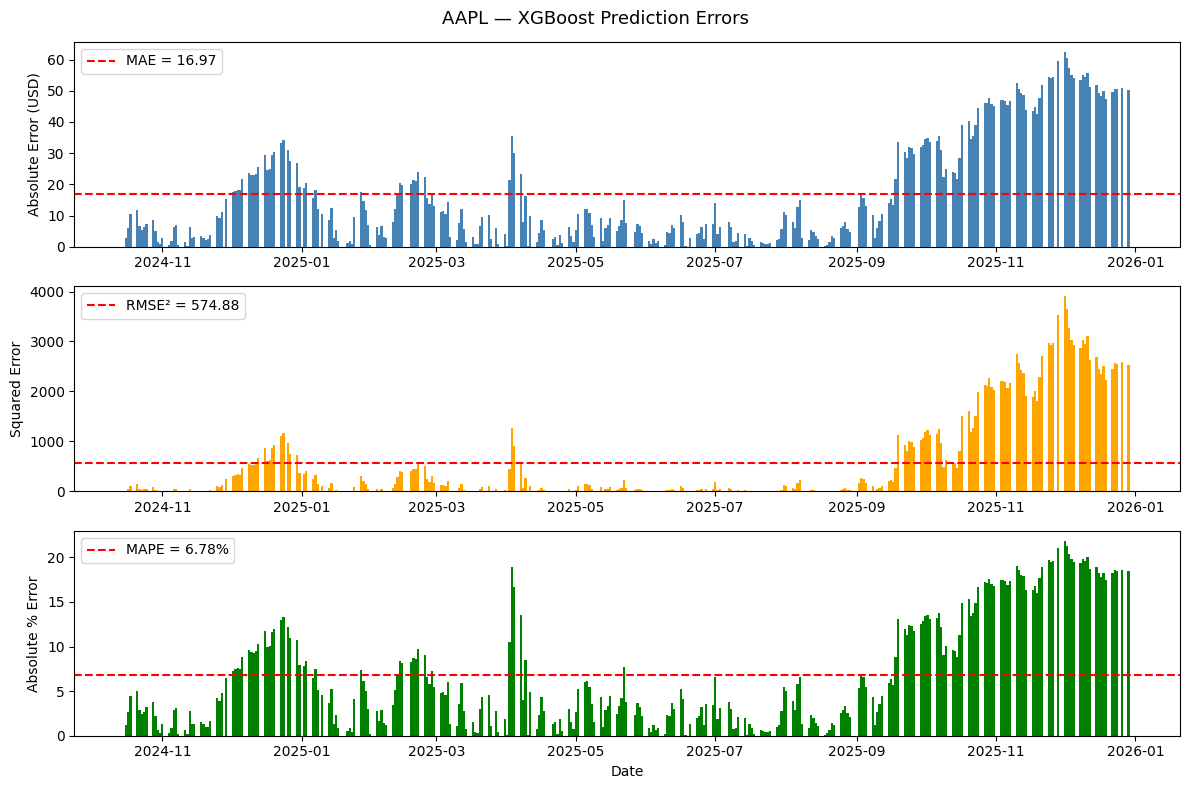

In [114]:
mae  = mean_absolute_error(actuals, predictions)
rmse = np.sqrt(mean_squared_error(actuals, predictions))
mape = np.mean(np.abs((actuals - predictions) / actuals)) * 100

print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}%")

errors     = actuals - predictions
eval_index = y_test.index

fig, axes = plt.subplots(3, 1, figsize=(12, 8))
fig.suptitle(f'{TICKER} — XGBoost Prediction Errors', fontsize=13)

axes[0].bar(eval_index, np.abs(errors), color='steelblue', width=1)
axes[0].axhline(mae, color='red', linestyle='--', label=f'MAE = {mae:.2f}')
axes[0].set_ylabel('Absolute Error (USD)')
axes[0].legend()

axes[1].bar(eval_index, errors**2, color='orange', width=1)
axes[1].axhline(rmse**2, color='red', linestyle='--', label=f'RMSE² = {rmse**2:.2f}')
axes[1].set_ylabel('Squared Error')
axes[1].legend()

pct_errors = np.abs((actuals - predictions) / actuals) * 100
axes[2].bar(eval_index, pct_errors, color='green', width=1)
axes[2].axhline(mape, color='red', linestyle='--', label=f'MAPE = {mape:.2f}%')
axes[2].set_ylabel('Absolute % Error')
axes[2].set_xlabel('Date')
axes[2].legend()

plt.tight_layout()
plt.show()


## Plot — Actual vs Predicted

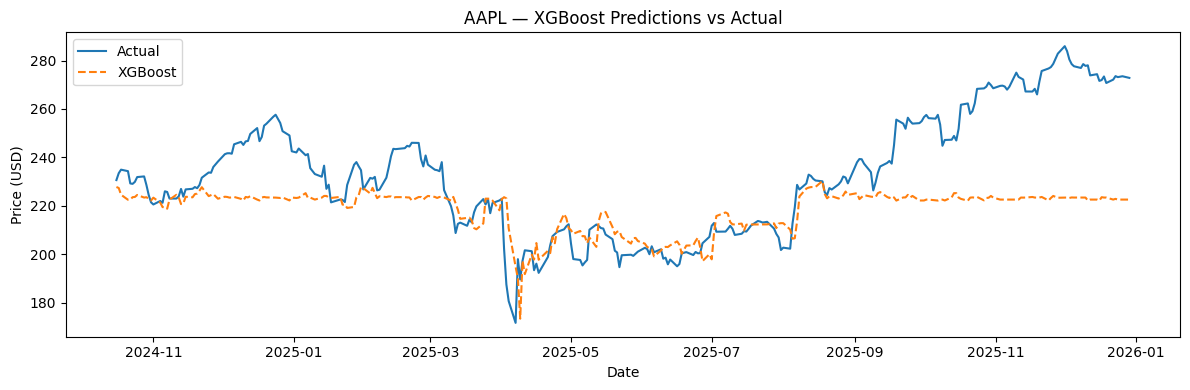

In [115]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(y_test.index, actuals,     label='Actual')
ax.plot(y_test.index, predictions, label='XGBoost', linestyle='--')
ax.set_title(f'{TICKER} — XGBoost Predictions vs Actual')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
plt.tight_layout()
plt.show()


## Feature Importance

XGBoost can tell us which features contributed most to its predictions.
A high importance score means the model relied heavily on that feature.

This is unique to tree-based models — ARIMA and LSTM cannot show this.

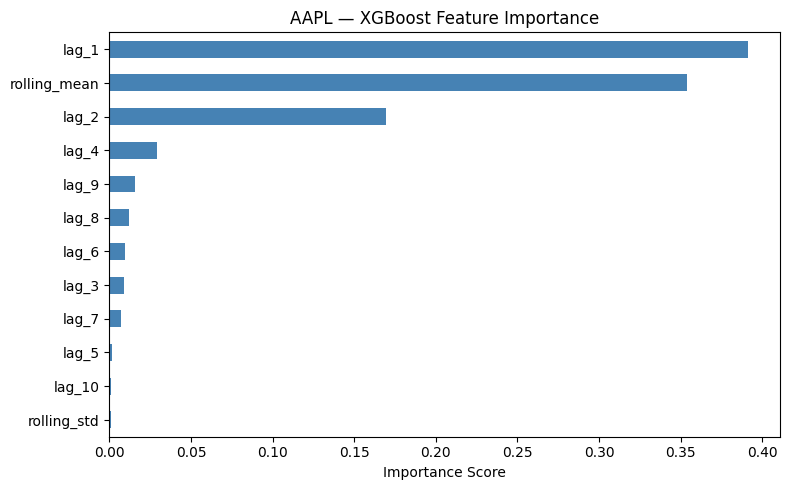

In [116]:
importance = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importance.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title(f'{TICKER} — XGBoost Feature Importance')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

## Save Results

Save predictions to `data/results/` so the model comparison notebook can load them.


In [117]:
import os
os.makedirs('../data/results', exist_ok=True)

results = pd.DataFrame({
    'Actual':    actuals,
    'Predicted': predictions,
}, index=y_test.index)

results.to_csv(f'../data/results/xgboost_{TICKER}.csv')
print(f"Saved {len(results)} rows to data/results/xgboost_{TICKER}.csv")


Saved 301 rows to data/results/xgboost_AAPL.csv
